# CC3092 — Laboratorio #2: Redes Neuronales Convolucionales

Clasificación multiclase de dígitos manuscritos (MNIST, 10 clases) comparando dos arquitecturas
entrenadas desde cero en PyTorch: un **MLP** que recibe la imagen aplanada y una **CNN** que la
recibe como tensor 2D.

## Parte 1: Imports y entorno

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from torchvision.datasets import MNIST
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Parte 2: Exploración y preparación de los datos

In [2]:
# MNIST viene ya separado en train (60k) y test (10k) por torchvision
train_full = MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_set = MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

print("Imágenes en train oficial:", len(train_full))
print("Imágenes en test oficial :", len(test_set))
print("Total                    :", len(train_full) + len(test_set))
print("Clases:", train_full.classes)

Imágenes en train oficial: 60000
Imágenes en test oficial : 10000
Total                    : 70000
Clases: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [3]:
# ¿están balanceadas las clases?
cnt_tr = pd.Series(train_full.targets.numpy()).value_counts().sort_index()
cnt_te = pd.Series(test_set.targets.numpy()).value_counts().sort_index()

dist = pd.DataFrame({"train (60k)": cnt_tr, "test (10k)": cnt_te})
dist["% train"] = (100 * dist["train (60k)"] / dist["train (60k)"].sum()).round(2)
dist.index.name = "dígito"
print(dist)
print(f"\nmin/max por clase en train: {cnt_tr.min()} / {cnt_tr.max()}")
print(f"desviación máxima respecto al 10% ideal: {(100 * cnt_tr / cnt_tr.sum() - 10).abs().max():.2f} pp")

        train (60k)  test (10k)  % train
dígito                                  
0              5923         980     9.87
1              6742        1135    11.24
2              5958        1032     9.93
3              6131        1010    10.22
4              5842         982     9.74
5              5421         892     9.04
6              5918         958     9.86
7              6265        1028    10.44
8              5851         974     9.75
9              5949        1009     9.91

min/max por clase en train: 5421 / 6742
desviación máxima respecto al 10% ideal: 1.24 pp


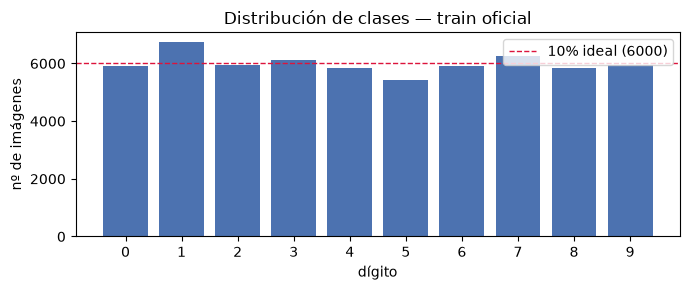

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(cnt_tr.index, cnt_tr.values, color="#4C72B0")
ax.axhline(len(train_full) / 10, color="crimson", ls="--", lw=1, label="10% ideal (6000)")
ax.set_xticks(range(10))
ax.set_xlabel("dígito")
ax.set_ylabel("nº de imágenes")
ax.set_title("Distribución de clases — train oficial")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# dimensión de cada imagen y rango de los píxeles
img, label = train_full[0]
raw = train_full.data  # tensor uint8 sin transformar

print("Tensor tras ToTensor():", tuple(img.shape), "| dtype:", img.dtype)
print(f"Rango tras ToTensor(): [{img.min():.1f}, {img.max():.1f}]")
print("Tensor crudo (dataset completo):", tuple(raw.shape), "| dtype:", raw.dtype)
print(f"Rango crudo: [{raw.min()}, {raw.max()}]")

x01 = raw.float() / 255.0
print(f"Media global (escala 0-1): {x01.mean():.4f} | Desv. estándar: {x01.std():.4f}")
print(f"Proporción de píxeles en 0 (fondo): {(raw == 0).float().mean():.2%}")

Tensor tras ToTensor(): (1, 28, 28) | dtype: torch.float32
Rango tras ToTensor(): [0.0, 1.0]
Tensor crudo (dataset completo): (60000, 28, 28) | dtype: torch.uint8
Rango crudo: [0, 255]


Media global (escala 0-1): 0.1307 | Desv. estándar: 0.3081
Proporción de píxeles en 0 (fondo): 80.88%


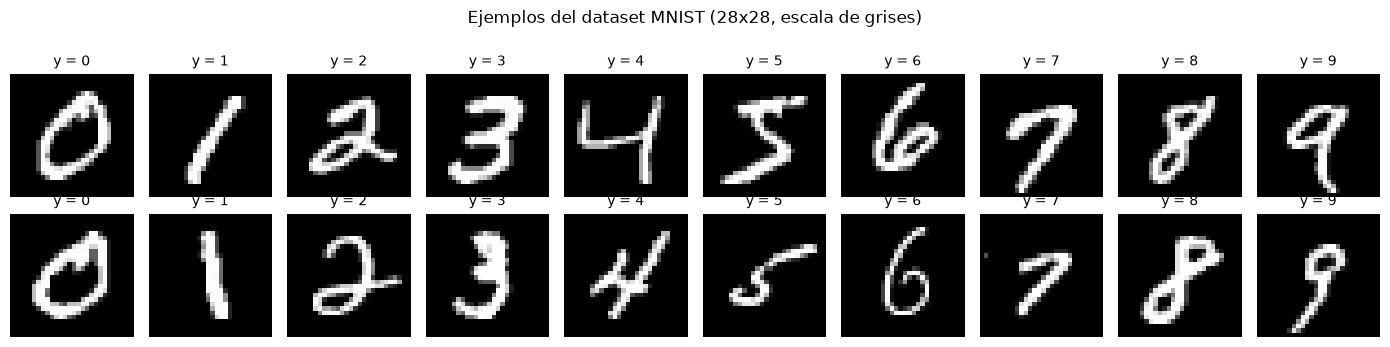

In [6]:
# 20 ejemplos: dos instancias distintas de cada dígito con su etiqueta
targets = train_full.targets.numpy()
fig, axes = plt.subplots(2, 10, figsize=(14, 3.4))
for d in range(10):
    idxs = np.where(targets == d)[0][:2]
    for row, i in enumerate(idxs):
        im, lab = train_full[i]
        axes[row, d].imshow(im.squeeze(), cmap="gray")
        axes[row, d].set_title(f"y = {lab}", fontsize=10)
        axes[row, d].axis("off")
plt.suptitle("Ejemplos del dataset MNIST (28x28, escala de grises)", y=1.02)
plt.tight_layout()
plt.show()

### División train / validación / test

El test oficial de 10 000 imágenes se reserva y **solo se usa una vez** al final. El train oficial de
60 000 se parte 80/20 en entrenamiento (48 000) y validación (12 000), que es el conjunto con el que
se comparan todas las iteraciones de hiperparámetros.

In [7]:
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(train_full), generator=g)
n_val = 12_000
val_idx, train_idx = perm[:n_val], perm[n_val:]

X_all = train_full.data.float().div(255.0).unsqueeze(1)  # (60000, 1, 28, 28) en [0, 1]
y_all = train_full.targets.clone()

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test = test_set.data.float().div(255.0).unsqueeze(1)
y_test = test_set.targets.clone()

print("train:", tuple(X_train.shape), "| val:", tuple(X_val.shape), "| test:", tuple(X_test.shape))
print("clases en validación:", pd.Series(y_val.numpy()).value_counts().sort_index().to_dict())

train: (48000, 1, 28, 28) | val: (12000, 1, 28, 28) | test: (10000, 1, 28, 28)
clases en validación: {0: 1179, 1: 1293, 2: 1196, 3: 1247, 4: 1179, 5: 1097, 6: 1212, 7: 1218, 8: 1206, 9: 1173}


In [8]:
# normalización: estadísticos calculados SOLO con el split de entrenamiento
MEAN, STD = X_train.mean().item(), X_train.std().item()
print(f"mean = {MEAN:.4f} | std = {STD:.4f}")


def normalize(x):
    return (x - MEAN) / STD


X_train_n, X_val_n, X_test_n = normalize(X_train), normalize(X_val), normalize(X_test)
print(f"rango train normalizado: [{X_train_n.min():.2f}, {X_train_n.max():.2f}]")
print(f"media/std train normalizado: {X_train_n.mean():.4f} / {X_train_n.std():.4f}")

# los tres splits caben en VRAM (~220 MB), así se evita el cuello de botella del DataLoader
train_ds = TensorDataset(X_train_n.to(device), y_train.to(device))
val_ds = TensorDataset(X_val_n.to(device), y_val.to(device))
test_ds = TensorDataset(X_test_n.to(device), y_test.to(device))

val_loader = DataLoader(val_ds, batch_size=1024)
test_loader = DataLoader(test_ds, batch_size=1024)
print("datasets listos en", device)

mean = 0.1306 | std = 0.3081


rango train normalizado: [-0.42, 2.82]


media/std train normalizado: 0.0000 / 1.0000


datasets listos en cuda


### Respuestas — Parte 2

**¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Están balanceadas?**

70 000 imágenes en total: 60 000 en el train oficial y 10 000 en el test oficial, con **10 clases**
(dígitos 0–9). Las clases están **prácticamente balanceadas pero no exactamente**: en train van de
5 421 imágenes (el 5, 9.04%) a 6 742 (el 1, 11.24%), es decir una desviación máxima de 1.24 puntos
porcentuales respecto al 10% ideal. Un desbalance de ese tamaño no exige ponderar la pérdida ni
remuestrear; sí justifica reportar métricas **macro** además de accuracy, para que las clases menos
frecuentes pesen igual en la evaluación.

**¿Cuál es la dimensión de cada imagen y qué rango de valores tienen los píxeles?**

Cada imagen es de **28x28 píxeles en un solo canal** (escala de grises). En crudo es un tensor `uint8`
con valores en **[0, 255]**; `ToTensor()` la convierte a `float32` de forma `(1, 28, 28)` en **[0, 1]**.
Aplanada son 784 features, que es la dimensión de entrada del MLP. El 80.9% de los píxeles son 0 puros:
la imagen es mayormente fondo negro con el trazo blanco centrado.

**¿Es necesario normalizar los valores de los píxeles?**

Sí. Con valores en [0, 255] los gradientes de la primera capa quedan a una escala dos órdenes de
magnitud mayor que los pesos, lo que obliga a learning rates diminutos y hace inestable el
entrenamiento. Aquí se aplican dos pasos: dividir por 255 (→ [0, 1]) y estandarizar con la media y
desviación del **split de entrenamiento** (`mean = 0.1306`, `std = 0.3081`, que coinciden con los
valores canónicos de MNIST). El resultado tiene media 0 y desviación 1, con rango [-0.42, 2.82].
Calcular los estadísticos solo con train evita filtrar información de validación/test.

**División de los datos**

- Entrenamiento: 48 000 imágenes (80% del train oficial).
- Validación: 12 000 imágenes (20%), con reparto por clase entre 1 097 y 1 293 → mantiene el balance del
  conjunto original.
- Test: las 10 000 imágenes oficiales, intactas hasta la evaluación final.

## Parte 3: Investigación — capas de PyTorch para la CNN

### Concepto previo: tensor

Un **tensor** (`torch.Tensor`) es un arreglo n-dimensional homogéneo, análogo a `np.ndarray`, pero con
dos capacidades extra: puede vivir en GPU (`.to("cuda")`) y registra las operaciones que lo producen
para que `autograd` calcule gradientes automáticamente (`requires_grad`, `.backward()`). Es la
estructura con la que viajan datos, parámetros y gradientes.

Las convenciones de forma que usa este lab:

| Objeto | Forma | Significado |
|---|---|---|
| Batch de imágenes | `(N, C, H, W)` | 128 imágenes de 1 canal 28x28 → `(128, 1, 28, 28)` |
| Entrada del MLP | `(N, D)` | la misma imagen aplanada → `(128, 784)` |
| Salida (logits) | `(N, K)` | una puntuación por clase → `(128, 10)` |

---

### 1. `nn.Conv2d`

**Propósito:** aplicar un banco de filtros (kernels) que se deslizan sobre la imagen. Cada filtro
aprende un patrón local (bordes, esquinas, trazos) y produce un *mapa de activación*; los pesos se
comparten entre todas las posiciones, lo que da **equivarianza a traslación** y muy pocos parámetros.

**Parámetros relevantes:**
- `in_channels` / `out_channels`: canales de entrada (1 en MNIST) y número de filtros a aprender.
- `kernel_size`: tamaño de la ventana (3 o 5 típicamente).
- `stride` (default 1): paso del deslizamiento; >1 reduce la resolución.
- `padding` (default 0): ceros añadidos al borde; `padding=k//2` conserva el tamaño espacial.
- `bias` (default `True`): redundante si va seguido de `BatchNorm2d`.

Tamaño de salida: `H_out = floor((H + 2p - k)/s) + 1`. Parámetros: `out*in*k*k + out`.

---

### 2. `nn.MaxPool2d`

**Propósito:** submuestrear tomando el **máximo** de cada ventana. Reduce resolución (menos cómputo),
amplía el campo receptivo y aporta invarianza a pequeños desplazamientos. No tiene parámetros
entrenables.

**Parámetros relevantes:** `kernel_size` (2 es lo habitual), `stride` (por defecto igual a
`kernel_size`), `padding`. Con `MaxPool2d(2)` una entrada 28x28 pasa a 14x14.

---

### 3. `nn.AvgPool2d`

**Propósito:** igual que el anterior pero promediando la ventana. Suaviza en lugar de quedarse con la
activación más fuerte: conserva información sobre la intensidad media de la región en vez de solo el
pico. Cuál de los dos conviene es una cuestión empírica, y en la Parte 4 se comparan manteniendo todo
lo demás fijo. Mismos parámetros: `kernel_size`, `stride`, `padding`.

---

### 4. `nn.BatchNorm2d`

**Propósito:** normalizar cada canal usando la media y varianza del batch, y luego reescalarlo con dos
parámetros aprendidos por canal (`gamma`, `beta`). Estabiliza la distribución de activaciones, permite
learning rates más altos, acelera la convergencia y actúa como regularizador suave.

**Parámetros relevantes:** `num_features` (= `out_channels` de la conv previa), `eps`, `momentum` (para
las estadísticas móviles usadas en inferencia), `affine`. Distingue `model.train()` de `model.eval()`:
en entrenamiento usa estadísticos del batch, en evaluación los acumulados.

---

### 5. `nn.Flatten`

**Propósito:** aplanar las dimensiones espaciales para conectar la parte convolucional con las capas
densas: `(N, C, H, W) → (N, C*H*W)`. No tiene parámetros. En el MLP es la primera capa, la que
convierte `(N, 1, 28, 28)` en `(N, 784)`.

**Parámetros relevantes:** `start_dim` (default 1, preserva la dimensión de batch) y `end_dim`.

---

### 6. `nn.CrossEntropyLoss`

**Propósito:** pérdida estándar de clasificación multiclase. Combina `log_softmax` + `NLLLoss` en una
sola operación numéricamente estable, por lo que **la red debe emitir logits crudos, sin softmax
final**. Espera `input` de forma `(N, K)` y `target` entero de forma `(N,)` con las clases.

**Parámetros relevantes:** `weight` (pesos por clase para datos desbalanceados; innecesario en MNIST),
`label_smoothing`, `reduction` (`"mean"` por defecto), `ignore_index`.

---

### 7. Campo receptivo (*receptive field*)

El campo receptivo de una unidad es la región de la imagen de entrada que puede influir en su valor.
Crece al apilar capas: `RF_l = RF_{l-1} + (k_l - 1) * prod(strides anteriores)`. En la CNN base de este
lab (conv3x3 → pool2 → conv3x3 → pool2):

| Capa | k | stride acumulado | RF |
|---|---|---|---|
| conv1 3x3 | 3 | 1 | 3 |
| pool1 2x2 | 2 | 1 | 4 |
| conv2 3x3 | 3 | 2 | 8 |
| pool2 2x2 | 2 | 2 | 10 |

Se pasa de mirar 3x3 píxeles a mirar 10x10 sobre 28x28: las primeras capas detectan trazos locales y
las profundas combinan esos trazos en partes del dígito. Por eso una CNN necesita profundidad: sin
ella el campo receptivo nunca cubre la figura completa.

---

### 8. ¿Por qué una CNN necesita menos parámetros que un MLP equivalente?

Tres razones:

1. **Conectividad local:** cada unidad se conecta solo a una vecindad `k x k`, no a los 784 píxeles.
2. **Pesos compartidos:** el mismo filtro se reutiliza en todas las posiciones, así que su coste no
   depende del tamaño de la imagen.
3. **Submuestreo:** el pooling reduce la resolución antes de llegar a las capas densas, que son las
   que concentran casi todos los parámetros.

Además el sesgo inductivo es el correcto para imágenes: un MLP con la imagen aplanada pierde la
vecindad espacial (dos píxeles adyacentes acaban en posiciones arbitrarias del vector), mientras la
CNN la respeta por construcción. La celda siguiente cuantifica la diferencia.

In [9]:
conv = nn.Conv2d(1, 32, kernel_size=3, padding=1)      # (1,28,28) -> (32,28,28)
lin = nn.Linear(28 * 28, 32 * 28 * 28)                  # misma transformación, densa

p_conv = sum(p.numel() for p in conv.parameters())
p_lin = sum(p.numel() for p in lin.parameters())

print(f"Conv2d(1->32, 3x3, pad=1):        {p_conv:>12,} parámetros")
print(f"nn.Linear(784 -> 25088) equiv.:   {p_lin:>12,} parámetros")
print(f"Factor de reducción:              {p_lin / p_conv:>12,.0f}x")

Conv2d(1->32, 3x3, pad=1):                 320 parámetros
nn.Linear(784 -> 25088) equiv.:     19,694,080 parámetros
Factor de reducción:                    61,544x


## Parte 4: Construcción y entrenamiento de las arquitecturas

### 4.1 Definición de los modelos

Ambas clases son configurables para poder variar hiperparámetros sin reescribir código. El MLP recibe la
imagen aplanada por `nn.Flatten` (784 features); la CNN la recibe como tensor `(N, 1, 28, 28)` y usa al
menos dos bloques `Conv2d → [BatchNorm2d] → ReLU → Pool`. Las dos terminan en una capa lineal de 10
salidas **sin softmax**, porque `nn.CrossEntropyLoss` lo aplica internamente.

In [10]:
class MLP(nn.Module):
    # MLP sobre la imagen aplanada: 784 -> hidden... -> 10

    def __init__(self, hidden=(128,), dropout=0.0, batchnorm=False, in_dim=784, n_classes=10):
        super().__init__()
        layers = [nn.Flatten()]
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    # bloques Conv2d -> [BatchNorm2d] -> ReLU -> Pool, y cabeza densa

    def __init__(self, channels=(16, 32), kernel_size=3, pool="max", batchnorm=False,
                 dropout=0.0, fc_hidden=128, n_classes=10):
        super().__init__()
        Pool = nn.MaxPool2d if pool == "max" else nn.AvgPool2d
        layers, prev = [], 1
        for c in channels:
            layers.append(nn.Conv2d(prev, c, kernel_size=kernel_size, padding=kernel_size // 2))
            if batchnorm:
                layers.append(nn.BatchNorm2d(c))
            layers.append(nn.ReLU())
            layers.append(Pool(2))
            prev = c
        self.features = nn.Sequential(*layers)

        with torch.no_grad():  # dimensión de aplanado, calculada con un forward ficticio
            flat = self.features(torch.zeros(1, 1, 28, 28)).numel()

        head = [nn.Flatten(), nn.Linear(flat, fc_hidden), nn.ReLU()]
        if dropout > 0:
            head.append(nn.Dropout(dropout))
        head.append(nn.Linear(fc_hidden, n_classes))  # logits
        self.classifier = nn.Sequential(*head)

    def forward(self, x):
        return self.classifier(self.features(x))


print(MLP(hidden=(256, 128)))
print(CNN(channels=(32, 64), batchnorm=True))

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bia

### 4.2 Rutina de entrenamiento y evaluación

`train_one_run` entrena una configuración registrando la pérdida de train y validación por epoch, y
devuelve las métricas de validación (accuracy, precision, recall y F1 en versión macro y weighted), el
número de parámetros entrenables y el tiempo de entrenamiento. La semilla se reinicia en cada corrida
para que las diferencias entre configuraciones vengan del hiperparámetro y no de la inicialización.

In [11]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def predict(model, loader, criterion):
    # devuelve (loss media, y_true, y_pred) sobre un loader
    model.eval()
    total, n, ys, ps = 0.0, 0, [], []
    for xb, yb in loader:
        out = model(xb)
        total += criterion(out, yb).item() * xb.size(0)
        n += xb.size(0)
        ys.append(yb.cpu())
        ps.append(out.argmax(1).cpu())
    return total / n, torch.cat(ys).numpy(), torch.cat(ps).numpy()


def classification_metrics(y_true, y_pred):
    pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": pm, "recall_macro": rm, "f1_macro": fm,
        "precision_w": pw, "recall_w": rw, "f1_w": fw,
    }


def build_model(c):
    if c["arch"] == "mlp":
        return MLP(hidden=c["hidden"], dropout=c["dropout"], batchnorm=c["batchnorm"])
    return CNN(channels=c["channels"], kernel_size=c["kernel_size"], pool=c["pool"],
               batchnorm=c["batchnorm"], dropout=c["dropout"], fc_hidden=c["fc_hidden"])


def train_one_run(c, verbose=True):
    torch.manual_seed(SEED)
    model = build_model(c).to(device)
    train_loader = DataLoader(train_ds, batch_size=c["batch_size"], shuffle=True)
    criterion = nn.CrossEntropyLoss()

    if c["optimizer"] == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=c["lr"], weight_decay=c["weight_decay"])
    else:
        opt = torch.optim.SGD(model.parameters(), lr=c["lr"], momentum=0.9,
                              weight_decay=c["weight_decay"])

    history = {"train_loss": [], "val_loss": []}
    t0 = time.time()
    for epoch in range(1, c["epochs"] + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)
        tr_loss = running / n
        va_loss, y_true, y_pred = predict(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        if verbose:
            print(f"  epoch {epoch:2d}/{c['epochs']} | train {tr_loss:.4f} | "
                  f"val {va_loss:.4f} | val acc {accuracy_score(y_true, y_pred):.4f}")

    elapsed = time.time() - t0
    va_loss, y_true, y_pred = predict(model, val_loader, criterion)
    metrics = classification_metrics(y_true, y_pred)
    metrics.update(val_loss=va_loss, params=count_params(model), train_time=elapsed)
    return model, history, metrics

### 4.3 Configuraciones a explorar

Se parte de un **baseline** por arquitectura y se cambian **uno o dos factores a la vez**, de modo que
cada resultado sea atribuible al cambio hecho. Se mantienen fijos `epochs=10`, `batch_size=128` y
`Adam(lr=1e-3)` salvo cuando son precisamente la variable bajo estudio. En total **14 iteraciones**
(7 por arquitectura).

| # | Config | Qué cambia respecto al baseline | Por qué |
|---|---|---|---|
| M1 | MLP `[128]` | baseline | referencia mínima |
| M2 | MLP `[256,128]` | más ancho y profundo | ¿ayuda más capacidad? |
| M3 | MLP `[512,256]` | aún más ancho | ¿escala la capacidad o saturar? |
| M4 | MLP `[256,128]` + dropout 0.3 | regularización | mitigar overfitting de M2 |
| M5 | MLP `[256,128]` + BatchNorm1d | normalización | efecto sobre convergencia |
| M6 | MLP `[256,128]`, lr 1e-2 | learning rate 10x | probar un lr agresivo |
| M7 | MLP `[256,128]` + BN + dropout 0.2 + wd 1e-4 | regularización combinada | combinar lo que funcionó |
| C1 | CNN `[16,32]` max-pool | baseline | dos capas convolucionales, mínimo del enunciado |
| C2 | CNN `[32,64]` | doble de filtros | ¿más filtros = mejores features? |
| C3 | CNN `[32,64]` + BatchNorm2d | normalización | efecto sobre convergencia |
| C4 | CNN `[32,64]` + BN + dropout 0.3 | regularización | reducir la brecha train/val |
| C5 | CNN `[32,64]` + BN, avg-pool | tipo de pooling | max vs. average |
| C6 | CNN `[32,64]` + BN + dropout 0.3, lr 1e-2 | learning rate 10x | probar un lr agresivo |
| C7 | CNN `[32,64,128]` + BN + dropout 0.3 | tercer bloque conv | más profundidad y campo receptivo |

In [12]:
BASE_MLP = {
    "arch": "mlp", "hidden": (128,), "dropout": 0.0, "batchnorm": False,
    "optimizer": "adam", "lr": 1e-3, "batch_size": 128, "epochs": 10, "weight_decay": 0.0,
}
BASE_CNN = {
    "arch": "cnn", "channels": (16, 32), "kernel_size": 3, "pool": "max", "fc_hidden": 128,
    "dropout": 0.0, "batchnorm": False,
    "optimizer": "adam", "lr": 1e-3, "batch_size": 128, "epochs": 10, "weight_decay": 0.0,
}


def cfg(base, name, **over):
    c = dict(base)
    c.update(over)
    c["name"] = name
    return c


configs = [
    cfg(BASE_MLP, "M1 baseline [128]"),
    cfg(BASE_MLP, "M2 [256,128]", hidden=(256, 128)),
    cfg(BASE_MLP, "M3 [512,256]", hidden=(512, 256)),
    cfg(BASE_MLP, "M4 [256,128] + dropout 0.3", hidden=(256, 128), dropout=0.3),
    cfg(BASE_MLP, "M5 [256,128] + BatchNorm", hidden=(256, 128), batchnorm=True),
    cfg(BASE_MLP, "M6 [256,128] lr=1e-2", hidden=(256, 128), lr=1e-2),
    cfg(BASE_MLP, "M7 [256,128] + BN + drop 0.2 + wd", hidden=(256, 128), batchnorm=True,
        dropout=0.2, weight_decay=1e-4),
    cfg(BASE_CNN, "C1 baseline [16,32] max"),
    cfg(BASE_CNN, "C2 [32,64] max", channels=(32, 64)),
    cfg(BASE_CNN, "C3 [32,64] + BatchNorm", channels=(32, 64), batchnorm=True),
    cfg(BASE_CNN, "C4 [32,64] + BN + dropout 0.3", channels=(32, 64), batchnorm=True, dropout=0.3),
    cfg(BASE_CNN, "C5 [32,64] + BN, avg-pool", channels=(32, 64), batchnorm=True, pool="avg"),
    cfg(BASE_CNN, "C6 [32,64] + BN + drop 0.3, lr=1e-2", channels=(32, 64), batchnorm=True,
        dropout=0.3, lr=1e-2),
    cfg(BASE_CNN, "C7 [32,64,128] + BN + dropout 0.3", channels=(32, 64, 128), batchnorm=True,
        dropout=0.3),
]

print(f"{len(configs)} configuraciones: "
      f"{sum(c['arch'] == 'mlp' for c in configs)} MLP + {sum(c['arch'] == 'cnn' for c in configs)} CNN")

14 configuraciones: 7 MLP + 7 CNN


### 4.4 Entrenamiento de las 14 iteraciones

In [13]:
results, histories, models = [], {}, {}

for i, c in enumerate(configs, start=1):
    print(f"\n=== [{i}/{len(configs)}] {c['name']} ===")
    model, history, metrics = train_one_run(c)
    histories[c["name"]] = history
    models[c["name"]] = model
    results.append({
        "id": i, "arch": c["arch"].upper(), "config": c["name"],
        "capas": str(c["hidden"]) if c["arch"] == "mlp" else str(c["channels"]),
        "pool": "-" if c["arch"] == "mlp" else c["pool"],
        "bn": c["batchnorm"], "dropout": c["dropout"], "wd": c["weight_decay"],
        "lr": c["lr"], "batch": c["batch_size"], "epochs": c["epochs"],
        **metrics,
    })
    print(f"  -> params {metrics['params']:,} | val acc {metrics['accuracy']:.4f} | "
          f"F1 macro {metrics['f1_macro']:.4f} | {metrics['train_time']:.1f}s")

res = pd.DataFrame(results)
print("\nentrenamiento total: %.1f s" % res["train_time"].sum())


=== [1/14] M1 baseline [128] ===


  epoch  1/10 | train 0.3294 | val 0.1857 | val acc 0.9457


  epoch  2/10 | train 0.1496 | val 0.1275 | val acc 0.9615


  epoch  3/10 | train 0.1059 | val 0.1071 | val acc 0.9664


  epoch  4/10 | train 0.0793 | val 0.1095 | val acc 0.9670


...

  epoch  7/10 | train 0.0168 | val 0.0343 | val acc 0.9910


  epoch  8/10 | train 0.0150 | val 0.0276 | val acc 0.9917


  epoch  9/10 | train 0.0141 | val 0.0317 | val acc 0.9919


  epoch 10/10 | train 0.0117 | val 0.0368 | val acc 0.9908
  -> params 241,994 | val acc 0.9908 | F1 macro 0.9907 | 18.4s



entrenamiento total: 142.6 s


### 4.5 Tabla de resultados de las iteraciones (métricas sobre validación)

In [14]:
cols = ["id", "arch", "config", "params", "lr", "dropout", "wd", "bn",
        "val_loss", "accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_w", "train_time"]
tabla = res[cols].copy()
tabla["params"] = tabla["params"].map("{:,}".format)
for c_ in ["val_loss", "accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_w"]:
    tabla[c_] = tabla[c_].round(4)
tabla["train_time"] = tabla["train_time"].round(1)

pd.set_option("display.width", 200, "display.max_columns", 50)
tabla

,id,arch,config,params,lr,dropout,wd,bn,val_loss,accuracy,precision_macro,recall_macro,f1_macro,f1_w,train_time
0,1,MLP,M1 baseline [128],"101,770",0.001,0.0,0.0000,False,0.0863,0.9756,0.9754,0.9756,0.9754,0.9756,6.2
1,2,MLP,"M2 [256,128]","235,146",0.001,0.0,0.0000,False,0.1051,0.9737,0.9739,0.9735,0.9735,0.9737,6.2
2,3,MLP,"M3 [512,256]","535,818",0.001,0.0,0.0000,False,0.0915,0.9791,0.9790,0.9790,0.9790,0.9791,6.8
3,4,MLP,"M4 [256,128] + dropout 0.3","235,146",0.001,0.3,0.0000,False,0.0713,0.9803,0.9803,0.9802,0.9802,0.9803,5.8
4,5,MLP,"M5 [256,128] + BatchNorm","235,914",0.001,0.0,0.0000,True,0.0746,0.9791,0.9790,0.9789,0.9790,0.9791,6.3
5,6,MLP,"M6 [256,128] lr=1e-2","235,146",0.010,0.0,0.0000,False,0.1921,0.9645,0.9650,0.9642,0.9644,0.9646,5.6
6,7,MLP,"M7 [256,128] + BN + drop 0.2 + wd","235,914",0.001,0.2,0.0001,True,0.0672,0.9795,0.9795,0.9794,0.9794,0.9795,7.3
7,8,CNN,"C1 baseline [16,32] max","206,922",0.001,0.0,0.0000,False,0.0380,0.9894,0.9894,0.9893,0.9894,0.9894,8.8
8,9,CNN,"C2 [32,64] max","421,642",0.001,0.0,0.0000,False,0.0476,0.9876,0.9878,0.9874,0.9875,0.9876,12.0
9,10,CNN,"C3 [32,64] + BatchNorm","421,834",0.001,0.0,0.0000,True,0.0400,0.9888,0.9886,0.9890,0.9887,0.9888,14.2


### Lectura de la tabla

**MLP.** El baseline `[128]` llega a 0.9756 de accuracy en validación. Ampliar a `[256,128]` (M2) lo
**empeora** (0.9737) y sube la val loss de 0.0863 a 0.1051: los 235 k parámetros memorizan el train
(train loss 0.0175) sin generalizar mejor. La capacidad extra solo rinde cuando se acompaña de
regularización: M4 (`[256,128]` + dropout 0.3) es la mejor del MLP con **0.9803** y la val loss baja a
0.0713 con los mismos parámetros que M2. BatchNorm sola (M5, 0.9791) y la combinación BN + dropout 0.2
+ weight decay (M7, 0.9795, val loss 0.0672 — la más baja del MLP) quedan a la par de M4. El lr
agresivo (M6, `lr=1e-2`) es claramente el peor: 0.9645 y val loss 0.1921.

**CNN.** Todas las variantes superan a cualquier MLP por un margen amplio: la peor CNN (C2, 0.9876)
está 0.7 pp por encima del mejor MLP. Detalles a destacar:

- Duplicar filtros de `[16,32]` a `[32,64]` (C1 → C2) **no ayuda**: 0.9894 → 0.9876. MNIST no necesita
  ese banco de filtros y el modelo se sobreajusta antes (train loss 0.0108).
- BatchNorm (C3) y BatchNorm + dropout (C4) recuperan lo perdido: 0.9888 y 0.9898.
- **Average pooling** (C5) es la mejor iteración global: **0.9922** con val loss 0.0308. Con trazos
  gruesos y centrados, promediar la ventana conserva más información que quedarse solo con el pico.
- El tercer bloque convolucional (C7) alcanza 0.9908 usando **menos parámetros** (241 994) que C5
  (421 834), porque cada pooling extra reduce el mapa que entra a la capa densa.

El punto más interesante es que C1 tiene **menos parámetros que el mejor MLP** (206 922 vs 235 146) y
comete casi la mitad de errores en validación: la ventaja de la CNN viene de *cómo* usa los parámetros,
no de cuántos tiene.

### 4.6 Curvas de pérdida (train vs. validación)

Se grafican las 7 iteraciones de cada arquitectura. La distancia entre la curva de train y la de
validación es la señal de overfitting; una validación que baja y luego sube indica que se pasó el punto
óptimo de epochs.

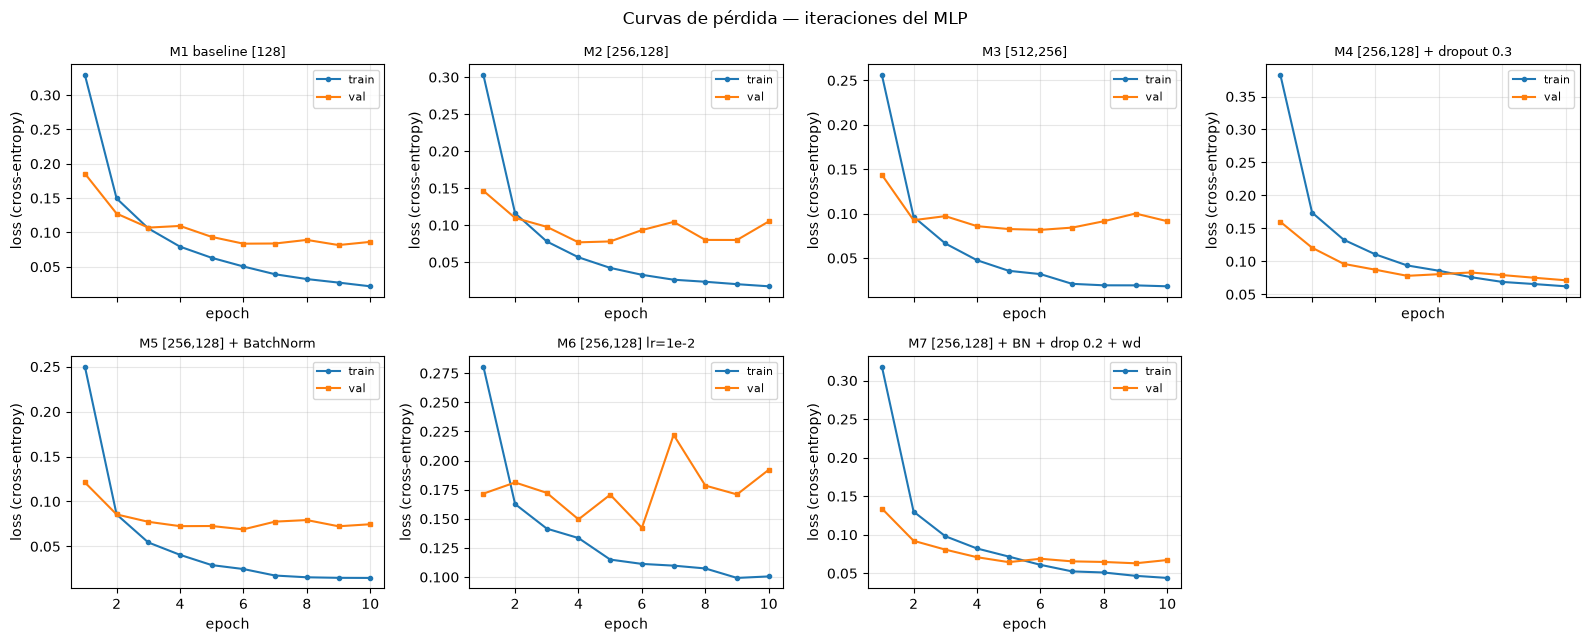

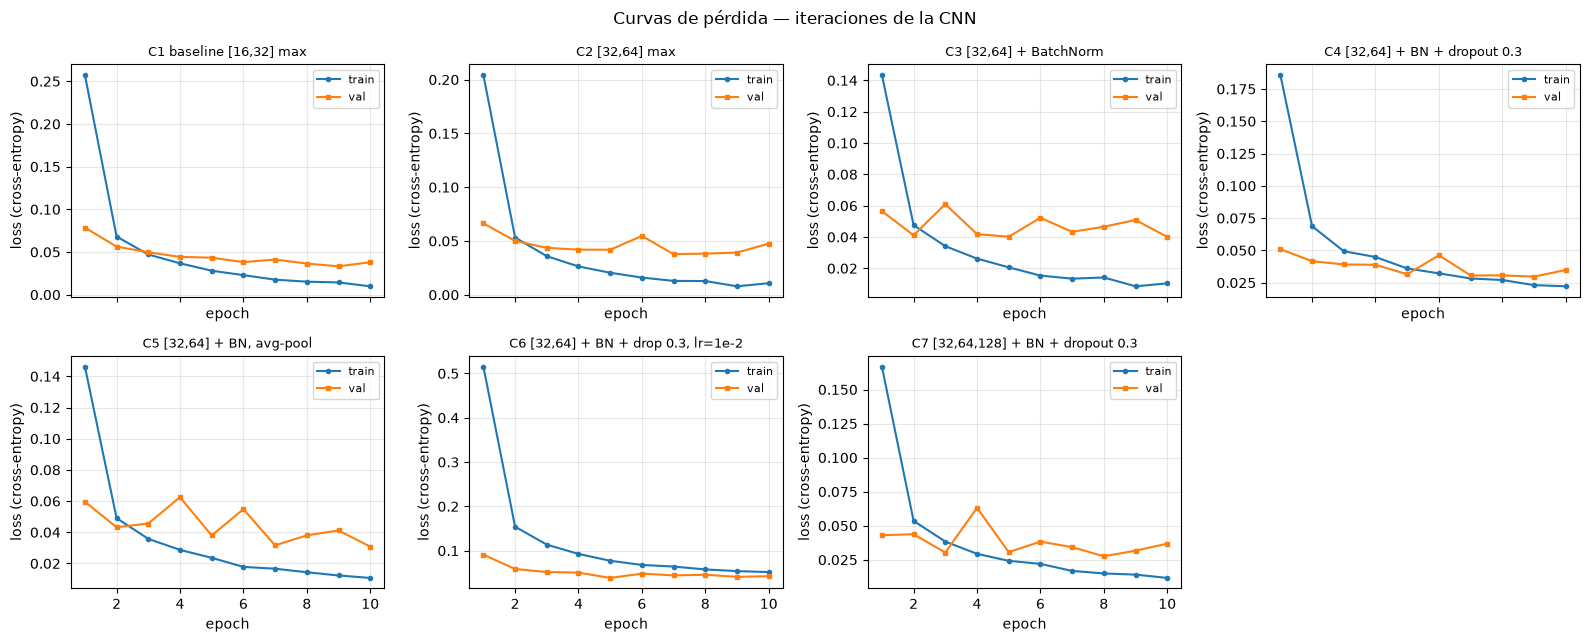

In [15]:
def plot_curves(arch, title):
    names = [r["config"] for r in results if r["arch"] == arch]
    fig, axes = plt.subplots(2, 4, figsize=(16, 6.5), sharex=True)
    for ax, name in zip(axes.ravel(), names):
        h = histories[name]
        ep = range(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], label="train", marker="o", ms=3)
        ax.plot(ep, h["val_loss"], label="val", marker="s", ms=3)
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss (cross-entropy)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    for ax in axes.ravel()[len(names):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_curves("MLP", "Curvas de pérdida — iteraciones del MLP")
plot_curves("CNN", "Curvas de pérdida — iteraciones de la CNN")

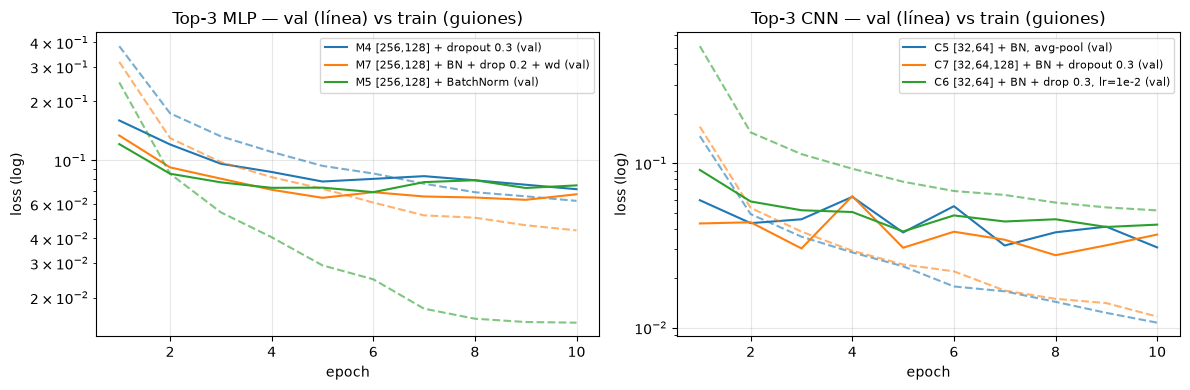

In [16]:
# vista en escala log de la brecha train/val de las mejores de cada arquitectura
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arch in zip(axes, ["MLP", "CNN"]):
    sub = res[res["arch"] == arch].nlargest(3, "f1_macro")
    for _, row in sub.iterrows():
        h = histories[row["config"]]
        ep = range(1, len(h["train_loss"]) + 1)
        p = ax.plot(ep, h["val_loss"], label=f"{row['config']} (val)")
        ax.plot(ep, h["train_loss"], ls="--", color=p[0].get_color(), alpha=0.6)
    ax.set_yscale("log")
    ax.set_title(f"Top-3 {arch} — val (línea) vs train (guiones)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss (log)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Señales de overfitting / underfitting

- **Overfitting claro en el MLP sin regularizar (M2, M3).** M2 termina con train loss 0.0175 frente a
  val loss 0.1051 (una brecha de ~6x) y su val loss deja de bajar en la epoch 4 mientras la de train
  sigue cayendo. Es el patrón de libro: la curva de validación se aplana o rebota hacia arriba y la de
  train se va a cero.
- **La regularización cierra la brecha.** En M4 (dropout 0.3) las curvas terminan casi pegadas (train
  0.0622, val 0.0713) y la val loss aún bajaba en la última epoch; en M7 pasa lo mismo (0.0440 vs
  0.0672). Es lo que hizo ganar accuracy: menos brecha, mejor validación.
- **Underfitting por learning rate.** M6 (`lr=1e-2`) es el único caso de mala optimización: su train
  loss se estanca alrededor de 0.10 —cinco veces más alto que sus pares— y la val loss oscila entre
  0.14 y 0.22 sin tendencia. El paso es demasiado grande y el optimizador rebota alrededor del mínimo.
  En la CNN el mismo lr (C6) queda amortiguado por BatchNorm: pierde poco en accuracy (0.9900) pero su
  train loss (0.0517) sigue siendo ~5x la de C5, así que también está subentrenada.
- **Las CNN también sobreajustan, pero desde mucho más abajo.** C2 acaba en train 0.0108 vs val 0.0476;
  su val loss oscila entre 0.0378 y 0.0547 en las últimas epochs. Añadir BN + dropout (C4, C7) reduce la
  oscilación y baja la val loss al rango 0.030–0.037.
- **Ruido entre epochs.** En las CNN la val loss se mueve ±0.02 de una epoch a otra (p. ej. C7: 0.0276
  en la epoch 8 y 0.0368 en la 10), así que diferencias de una décima de punto porcentual entre
  configuraciones cercanas no son concluyentes; sí lo es la separación MLP vs. CNN.

### 4.7 Evaluación final sobre test

Se elige la mejor configuración de cada arquitectura por **F1-score macro de validación** y se evalúa
**una única vez** sobre las 10 000 imágenes de test.

In [17]:
best = {}
for arch in ["MLP", "CNN"]:
    row = res[res["arch"] == arch].sort_values(["f1_macro", "val_loss"],
                                               ascending=[False, True]).iloc[0]
    best[arch] = row
    print(f"Mejor {arch}: {row['config']} | val F1 macro {row['f1_macro']:.4f} | "
          f"val acc {row['accuracy']:.4f} | {row['params']:,} params")

Mejor MLP: M4 [256,128] + dropout 0.3 | val F1 macro 0.9802 | val acc 0.9803 | 235,146 params
Mejor CNN: C5 [32,64] + BN, avg-pool | val F1 macro 0.9922 | val acc 0.9922 | 421,834 params


In [18]:
criterion = nn.CrossEntropyLoss()
test_results, test_preds = {}, {}

for arch, row in best.items():
    model = models[row["config"]]
    loss, y_true, y_pred = predict(model, test_loader, criterion)
    m = classification_metrics(y_true, y_pred)
    m.update(test_loss=loss, params=row["params"], train_time=row["train_time"],
             config=row["config"])
    test_results[arch] = m
    test_preds[arch] = (y_true, y_pred)
    print(f"\n--- {arch} ({row['config']}) sobre TEST ---")
    print(f"loss {loss:.4f} | accuracy {m['accuracy']:.4f} | precision macro {m['precision_macro']:.4f} "
          f"| recall macro {m['recall_macro']:.4f} | F1 macro {m['f1_macro']:.4f}")
    print(classification_report(y_true, y_pred, digits=4))


--- MLP (M4 [256,128] + dropout 0.3) sobre TEST ---
loss 0.0709 | accuracy 0.9788 | precision macro 0.9788 | recall macro 0.9786 | F1 macro 0.9787
              precision    recall  f1-score   support

           0     0.9848    0.9898    0.9873       980
           1     0.9851    0.9930    0.9890      1135
           2     0.9872    0.9700    0.9785      1032
           3     0.9802    0.9782    0.9792      1010
           4     0.9823    0.9593    0.9706       982
           5     0.9787    0.9787    0.9787       892
           6     0.9772    0.9823    0.9797       958
           7     0.9740    0.9835    0.9787      1028
           8     0.9774    0.9764    0.9769       974
           9     0.9609    0.9752    0.9680      1009

    accuracy                         0.9788     10000
   macro avg     0.9788    0.9786    0.9787     10000
weighted avg     0.9788    0.9788    0.9788     10000




--- CNN (C5 [32,64] + BN, avg-pool) sobre TEST ---
loss 0.0256 | accuracy 0.9932 | precision macro 0.9932 | recall macro 0.9931 | F1 macro 0.9932
              precision    recall  f1-score   support

           0     0.9909    0.9980    0.9944       980
           1     0.9965    0.9965    0.9965      1135
           2     0.9903    0.9942    0.9923      1032
           3     0.9960    0.9950    0.9955      1010
           4     0.9939    0.9959    0.9949       982
           5     0.9944    0.9922    0.9933       892
           6     0.9979    0.9864    0.9921       958
           7     0.9922    0.9893    0.9907      1028
           8     0.9867    0.9908    0.9887       974
           9     0.9931    0.9931    0.9931      1009

    accuracy                         0.9932     10000
   macro avg     0.9932    0.9931    0.9932     10000
weighted avg     0.9932    0.9932    0.9932     10000



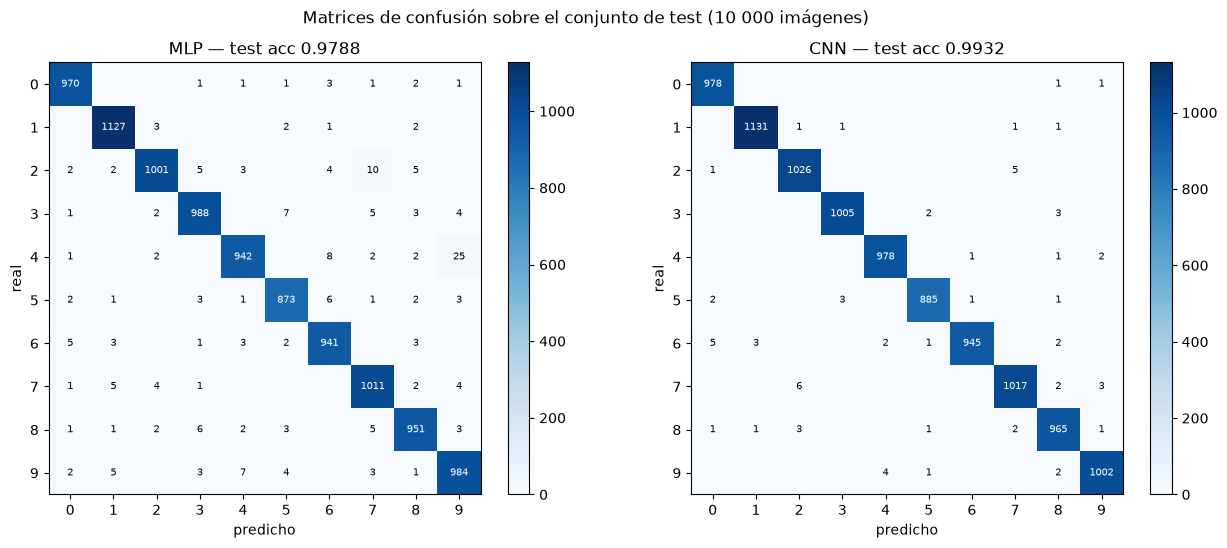

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, arch in zip(axes, ["MLP", "CNN"]):
    y_true, y_pred = test_preds[arch]
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    for i in range(10):
        for j in range(10):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(f"{arch} — test acc {test_results[arch]['accuracy']:.4f}")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Matrices de confusión sobre el conjunto de test (10 000 imágenes)")
plt.tight_layout()
plt.show()

In [20]:
# errores más frecuentes de cada modelo (fuera de la diagonal)
for arch in ["MLP", "CNN"]:
    y_true, y_pred = test_preds[arch]
    cm = confusion_matrix(y_true, y_pred)
    off = [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j and cm[i, j] > 0]
    off.sort(reverse=True)
    total_err = sum(c for c, _, _ in off)
    print(f"{arch}: {total_err} errores de 10 000 ({total_err / 100:.2f}%). Top 6 confusiones:")
    for c_, i, j in off[:6]:
        print(f"   real {i} -> predicho {j}: {c_}")
    print()

MLP: 212 errores de 10 000 (2.12%). Top 6 confusiones:
   real 4 -> predicho 9: 25
   real 2 -> predicho 7: 10
   real 4 -> predicho 6: 8
   real 9 -> predicho 4: 7
   real 3 -> predicho 5: 7
   real 8 -> predicho 3: 6

CNN: 68 errores de 10 000 (0.68%). Top 6 confusiones:
   real 7 -> predicho 2: 6
   real 6 -> predicho 0: 5
   real 2 -> predicho 7: 5
   real 9 -> predicho 4: 4
   real 8 -> predicho 2: 3
   real 7 -> predicho 9: 3



### Resultados en test

| Modelo | accuracy | precision (macro) | recall (macro) | F1 (macro) | loss | errores |
|---|---|---|---|---|---|---|
| MLP — M4 `[256,128]` + dropout 0.3 | 0.9788 | 0.9788 | 0.9786 | 0.9787 | 0.0709 | 212 / 10 000 |
| CNN — C5 `[32,64]` + BN, avg-pool | **0.9932** | **0.9932** | **0.9931** | **0.9932** | **0.0256** | **68 / 10 000** |

Las métricas de test son consistentes con validación (el MLP pierde 0.15 pp, la CNN gana 0.10 pp, dentro
del ruido esperable), lo que confirma que la selección por F1 macro de validación no sobreajustó al
conjunto de selección.

**Matrices de confusión.** El MLP concentra sus fallos en un puñado de pares: **4 → 9 con 25 casos** es
por sí solo el 12% de todos sus errores, seguido de 2 → 7 (10), 4 → 6 (8) y 9 → 4 (7). Sus peores clases
son el 9 (F1 0.9680) y el 4 (F1 0.9706), precisamente las que comparten el trazo vertical con lazo
superior. La CNN reparte los errores de forma mucho más uniforme: su confusión más frecuente son solo 6
casos (7 → 2) y su peor clase (el 8, F1 0.9887) sigue por encima de la mejor clase del MLP salvo el 1.
La CNN también atenúa el par 4/9 que domina los errores del MLP: 9 → 4 baja de 7 a 4 casos y 4 → 9
ni aparece entre sus seis confusiones más frecuentes (≤ 3 casos, frente a 25).

## Parte 5: Comparación de arquitecturas

In [21]:
comp = pd.DataFrame([{
    "arquitectura": arch,
    "configuración": m["config"],
    "params entrenables": m["params"],
    "test accuracy": round(m["accuracy"], 4),
    "test precision (macro)": round(m["precision_macro"], 4),
    "test recall (macro)": round(m["recall_macro"], 4),
    "test F1 (macro)": round(m["f1_macro"], 4),
    "test loss": round(m["test_loss"], 4),
    "tiempo entren. (s)": round(m["train_time"], 1),
    "s / epoch": round(m["train_time"] / 10, 2),
} for arch, m in test_results.items()])

comp_t = comp.set_index("arquitectura").T
print(comp_t.to_string())

mlp_m, cnn_m = test_results["MLP"], test_results["CNN"]
print(f"\nParámetros: CNN {cnn_m['params']:,} vs MLP {mlp_m['params']:,} "
      f"({cnn_m['params'] / mlp_m['params']:.2f}x)")
print(f"Reducción de error en test: {(1 - mlp_m['accuracy']) * 100:.2f}% -> "
      f"{(1 - cnn_m['accuracy']) * 100:.2f}% "
      f"({(1 - (1 - cnn_m['accuracy']) / (1 - mlp_m['accuracy'])) * 100:.1f}% menos errores)")

arquitectura                                   MLP                        CNN
configuración           M4 [256,128] + dropout 0.3  C5 [32,64] + BN, avg-pool
params entrenables                          235146                     421834
test accuracy                               0.9788                     0.9932
test precision (macro)                      0.9788                     0.9932
test recall (macro)                         0.9786                     0.9931
test F1 (macro)                             0.9787                     0.9932
test loss                                   0.0709                     0.0256
tiempo entren. (s)                             5.8                       15.4
s / epoch                                     0.58                       1.54

Parámetros: CNN 421,834 vs MLP 235,146 (1.79x)
Reducción de error en test: 2.12% -> 0.68% (67.9% menos errores)


In [22]:
# ¿dónde están los parámetros de la CNN?
cnn_best = models[best["CNN"]["config"]]
p_feat = sum(p.numel() for p in cnn_best.features.parameters())
p_head = sum(p.numel() for p in cnn_best.classifier.parameters())
print(f"CNN — bloques convolucionales: {p_feat:>9,} params ({p_feat / (p_feat + p_head):6.1%})")
print(f"CNN — cabeza densa:            {p_head:>9,} params ({p_head / (p_feat + p_head):6.1%})")

CNN — bloques convolucionales:    19,008 params (  4.5%)
CNN — cabeza densa:              402,826 params ( 95.5%)


In [23]:
# tiempo de inferencia sobre las 10 000 imágenes de test
@torch.no_grad()
def inference_time(model, loader, repeats=20, warmup=5):
    model.eval()
    for _ in range(warmup):  # warm-up: evita medir la subida de reloj de la GPU
        for xb, _ in loader:
            model(xb)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(repeats):
        for xb, _ in loader:
            model(xb)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / repeats

for arch in ["MLP", "CNN"]:
    t = inference_time(models[best[arch]["config"]], test_loader)
    test_results[arch]["infer_time"] = t
    print(f"{arch}: {t * 1000:.1f} ms para 10 000 imágenes "
          f"({t / 10_000 * 1e6:.2f} µs por imagen)")

MLP: 54.5 ms para 10 000 imágenes (5.45 µs por imagen)


CNN: 89.6 ms para 10 000 imágenes (8.96 µs por imagen)


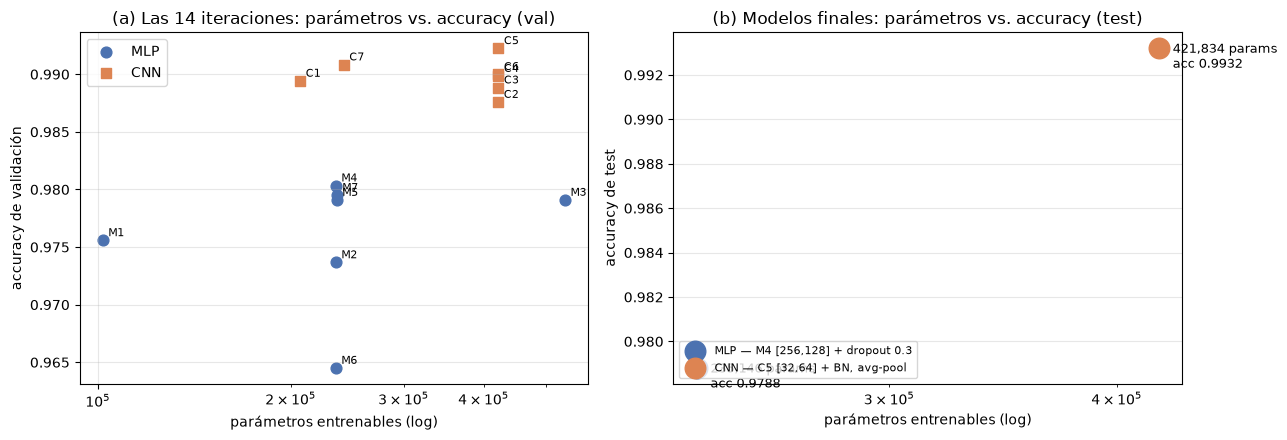

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) todas las iteraciones: parámetros vs accuracy de validación
ax = axes[0]
for arch, color, mk in [("MLP", "#4C72B0", "o"), ("CNN", "#DD8452", "s")]:
    sub = res[res["arch"] == arch]
    ax.scatter(sub["params"], sub["accuracy"], c=color, marker=mk, s=60, label=arch)
    for _, r_ in sub.iterrows():
        ax.annotate(r_["config"].split()[0], (r_["params"], r_["accuracy"]),
                    fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("parámetros entrenables (log)")
ax.set_ylabel("accuracy de validación")
ax.set_title("(a) Las 14 iteraciones: parámetros vs. accuracy (val)")
ax.legend()
ax.grid(alpha=0.3)

# (b) mejores modelos: parámetros vs accuracy de test
ax = axes[1]
for arch, color in [("MLP", "#4C72B0"), ("CNN", "#DD8452")]:
    m = test_results[arch]
    ax.scatter(m["params"], m["accuracy"], s=220, c=color, label=f"{arch} — {m['config']}")
    ax.annotate(f"{m['params']:,} params\nacc {m['accuracy']:.4f}",
                (m["params"], m["accuracy"]), fontsize=9, xytext=(10, -14),
                textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("parámetros entrenables (log)")
ax.set_ylabel("accuracy de test")
ax.set_title("(b) Modelos finales: parámetros vs. accuracy (test)")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Lectura de la comparación

| Criterio | MLP (M4) | CNN (C5) |
|---|---|---|
| Parámetros entrenables | 235 146 | 421 834 (1.79x) |
| Accuracy en test | 0.9788 | 0.9932 |
| F1 macro en test | 0.9787 | 0.9932 |
| Tasa de error | 2.12% | 0.68% (−67.9%) |
| Entrenamiento (10 epochs) | 5.8 s (0.58 s/epoch) | 15.4 s (1.54 s/epoch) |
| Inferencia (10 000 imágenes) | 54.5 ms (5.45 µs/img) | 89.6 ms (8.96 µs/img) |

- **Parámetros vs. calidad: no hay relación monótona.** El MLP más grande de todos (M3, 535 818 params)
  se queda en 0.9791 de validación, mientras que la CNN más pequeña (C1, 206 922 params — un 12% menos
  que el MLP final) llega a 0.9894. Dentro de cada arquitectura los parámetros extra rinden poco o nada
  (M2 empeora respecto a M1, C2 empeora respecto a C1); lo que mueve la aguja es el sesgo inductivo y la
  regularización. El panel (a) muestra esa separación: dos nubes horizontales, no una tendencia creciente.
- **Dónde vive el costo de la CNN.** Solo el **4.5% de sus parámetros (19 008)** está en los bloques
  convolucionales; el 95.5% restante (402 826) está en la cabeza densa que sigue al aplanado. Es decir,
  la parte que aporta el poder de representación es casi gratis en memoria, y el modelo se podría
  encoger drásticamente reduciendo la capa densa (C7 lo confirma: 241 994 params y 0.9908 en validación).
- **Costo temporal.** La CNN es ~2.7x más lenta de entrenar y ~1.6x más lenta en inferencia, pero en
  términos absolutos ambas son triviales para este problema: 15 s de entrenamiento completo y 9 µs por
  imagen en GPU.

## Parte 6: Discusión y análisis

**¿Qué cambio de hiperparámetro tuvo el mayor impacto positivo y el mayor impacto negativo en cada
arquitectura?**

| | Mayor impacto positivo | Mayor impacto negativo |
|---|---|---|
| MLP | **Dropout 0.3** (M2 → M4): 0.9737 → 0.9803 en validación (+0.66 pp) y val loss 0.1051 → 0.0713 | **`lr=1e-2`** (M6): 0.9737 → 0.9645 (−0.92 pp) y val loss hasta 0.1921 |
| CNN | **Average pooling** (C3 → C5): 0.9888 → 0.9922 (+0.34 pp), la mejor val loss del lab (0.0308) | **Duplicar filtros sin regularizar** (C1 → C2): 0.9894 → 0.9876 (−0.18 pp) |

En el MLP el factor decisivo fue regularizar, no crecer; en la CNN, un detalle arquitectónico (el tipo
de pooling) pesó más que el número de filtros. El learning rate alto fue el cambio más destructivo en
ambas, aunque en la CNN BatchNorm amortiguó el daño (C6 mantiene 0.9900).

**¿Observaron overfitting o underfitting? ¿Cómo lo identificaron y cómo lo mitigaron?**

Sí, ambos. **Overfitting** en M2, M3 y C2: la val loss se aplana o sube mientras la de train sigue
cayendo, con brechas de hasta 6x (M2: 0.0175 vs 0.1051). Se mitigó con dropout (M4, C4), BatchNorm (M5,
C3) y weight decay (M7), y en la CNN también reduciendo el tamaño del mapa que llega a la capa densa
(C7). **Underfitting** en M6 y C6: con `lr=1e-2` la train loss se estanca muy por encima de la de sus
pares (0.10 y 0.0517 frente a ~0.02) y la validación oscila sin tendencia; se identificó comparando la
train loss final entre configuraciones y se corrigió volviendo a `lr=1e-3`.

**¿La regularización mejoró el desempeño en validación? ¿Qué método funcionó mejor en cada arquitectura?**

Sí, y de forma clara en el MLP: **dropout** fue el mejor método ahí (+0.66 pp respecto a la misma red sin
regularizar), porque el MLP es el modelo que más sobreajusta —cada píxel tiene su propio peso y puede
memorizar patrones concretos del train— y apagar unidades al azar lo obliga a repartir la evidencia
entre neuronas. En la CNN el efecto es menor porque la arquitectura ya regulariza por diseño (pesos
compartidos y pooling); ahí lo que más aportó fue **BatchNorm** —estabiliza el entrenamiento y permite
absorber incluso un lr 10x mayor— y el dropout solo añadió +0.10 pp (C3 → C4). Combinar todo no fue
mejor que elegir bien: M7 (BN + dropout + weight decay) empató con M4, que solo usa dropout.

**¿Cuál obtuvo mejor desempeño en test y cómo se relaciona con los parámetros y el tratamiento de la
información espacial?**

La CNN: 0.9932 vs 0.9788 de accuracy, es decir **67.9% menos errores** (68 contra 212 de 10 000). Usa
1.79x los parámetros del MLP, pero la relación no es causal: la CNN más pequeña del lab (C1, 206 922
params) tiene *menos* parámetros que el MLP final y también lo supera holgadamente (0.9894 en
validación), y el MLP más grande (M3, 535 818 params) no llega a 0.98. La diferencia está en la
información espacial: el MLP recibe un vector de 784 valores donde la vecindad se pierde —dos píxeles
contiguos quedan en posiciones arbitrarias del vector y no hay nada que le diga al modelo que están
relacionados—, así que debe aprender cada patrón en cada posición por separado. La CNN comparte los
filtros en toda la imagen y amplía el campo receptivo con la profundidad (3 → 10 píxeles en la
arquitectura base), de modo que aprende una vez qué es un trazo y lo reconoce en cualquier lugar. De
hecho solo el 4.5% de los parámetros de la CNN está en las convoluciones: la parte que le da la ventaja
es la más barata.

**¿En qué tipo de errores se equivoca más cada modelo?**

El MLP falla de forma **sistemática en pares de dígitos con trazos parecidos**: 4 → 9 (25 casos, el 12%
de sus errores), 2 → 7 (10), 4 → 6 (8), 9 → 4 (7). Al perder la estructura espacial, no distingue el
detalle que separa un 4 abierto de un 9 cerrado, y sus peores clases son justamente el 9 (F1 0.9680) y
el 4 (F1 0.9706). La CNN tiene errores **dispersos y sin patrón dominante**: su confusión más frecuente
son 6 casos (7 → 2) y ninguna clase baja de 0.9887 de F1; el par 4/9 deja de dominar (9 → 4 son 4 casos y 4 → 9 no
figura entre sus seis confusiones más frecuentes). Lo
que le queda son dígitos genuinamente ambiguos o mal escritos, el tipo de error en el que también
dudaría una persona.

**Si tuvieran que desplegar en producción priorizando exactitud y eficiencia, ¿qué arquitectura elegirían?**

La **CNN**, sin dudarlo. Triplica la calidad en la métrica que importa (0.68% de error frente a 2.12%) y
el precio en eficiencia es marginal en términos absolutos: 15 s de entrenamiento completo y 9 µs por
imagen contra 5 µs del MLP. Si el despliegue fuera en un dispositivo con memoria muy limitada, la opción
concreta sería **C1** (`[16,32]`, 206 922 params, 0.9894 en validación) o **C7** (`[32,64,128]`, 241 994
params, 0.9908): ambas pesan menos que el MLP final y siguen superándolo por un margen amplio. La
optimización más rentable, en cualquier caso, es recortar la cabeza densa —el 95.5% de los parámetros—
por ejemplo con global average pooling, que reduciría el modelo casi un orden de magnitud sin tocar la
parte convolucional que hace el trabajo.